# Part 1: Data Audit, EDA & Business Understanding

## D2C Customer Churn Intelligence

Author: Apurva Jain

### Objective
Perform data audit, exploratory data analysis (EDA), identify churn-risk patterns, and provide business recommendations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## 1. Data Loading

In [2]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
tickets = pd.read_csv("support_tickets.csv")
web = pd.read_csv("web_events_snapshot.csv")
churn = pd.read_csv("churn_labels.csv")
interventions = pd.read_csv("intervention_history.csv")
rfm = pd.read_csv("rfm_modeling_snapshot.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


## 2. Dataset Overview

In [3]:
datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web": web,
    "churn": churn,
    "interventions": interventions,
    "rfm": rfm
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (2400, 9)
orders: (10009, 10)
tickets: (1921, 8)
web: (2400, 10)
churn: (2400, 4)
interventions: (2400, 5)
rfm: (2400, 29)


In [4]:
for name, df in datasets.items():
    print("\n" + "="*50)
    print(name.upper())
    display(df.head())


CUSTOMERS


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes



ORDERS


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0



TICKETS


...

,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train



INTERVENTIONS


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium



RFM


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


## 3. Schema Inspection

In [5]:
for name, df in datasets.items():
    print("\n" + "="*60)
    print(name.upper())
    print(df.info())


CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB
None

ORDERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 2  

## 4. Data Quality Audit

In [6]:
#Missing values analysis
for name, df in datasets.items():
    print("\n" + "="*50)
    print(name.upper())
    print(df.isnull().sum())


CUSTOMERS
customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

ORDERS
order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

TICKETS
ticket_id           0
customer_id         0
ticket_date         0
issue_type          0
support_channel     0
resolution_hours    0
sentiment_score     0
reopened            0
dtype: int64

WEB
customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d        0
campaign_clicks_30d    0
last_visit_days_ago    0
dtype: int64

CHURN
customer_id       0
snapshot_d

In [7]:
#Duplicate records
for name, df in datasets.items():
    print(f"\n{name}")
    print("Duplicate Rows:", df.duplicated().sum())


customers
Duplicate Rows: 0

orders
Duplicate Rows: 0

tickets
Duplicate Rows: 0

web
Duplicate Rows: 0

churn
Duplicate Rows: 0

interventions
Duplicate Rows: 0

rfm
Duplicate Rows: 0


In [8]:
#Duplicate-like Orders
dup_orders = orders[
    orders["order_id"].str.contains("_DUP", na=False)
]

print("Duplicate-like Orders:", len(dup_orders))

dup_orders.head()

Duplicate-like Orders: 12


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0


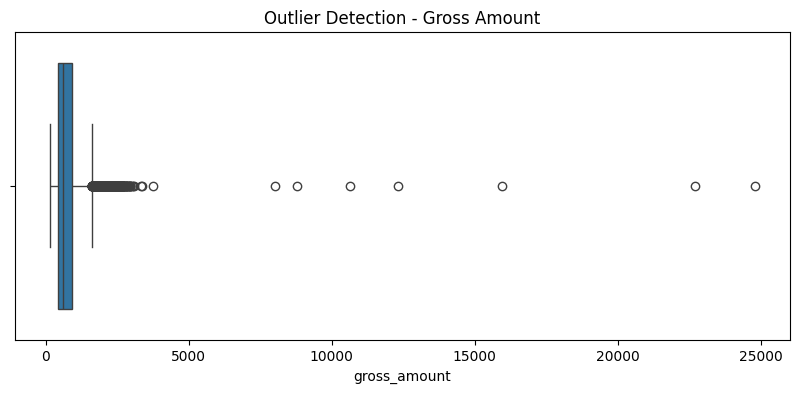

In [9]:
#Outlier detection
plt.figure(figsize=(10,4))

sns.boxplot(
    x=orders["gross_amount"]
)

plt.title("Outlier Detection - Gross Amount")

plt.show()

In [10]:
#Leakage Risk Check
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

future_orders = orders[
    orders["order_date"] > "2025-09-30"
]

print("Post Snapshot Orders:")
print(future_orders.shape)

Post Snapshot Orders:
(1872, 10)


In [11]:
#join validation
print("Customers:", customers["customer_id"].nunique())

print("Orders:", orders["customer_id"].nunique())

print("Tickets:", tickets["customer_id"].nunique())

print("Web:", web["customer_id"].nunique())

print("Churn:", churn["customer_id"].nunique())

Customers: 2400
Orders: 2400
Tickets: 1247
Web: 2400
Churn: 2400


In [13]:
#missing customer ids
missing_ticket_customers = (
    set(customers.customer_id)
    - set(tickets.customer_id)
)

print(
    "Customers without tickets:",
    len(missing_ticket_customers)
)

Customers without tickets: 1153


## 5. Exploratory Data Analysis

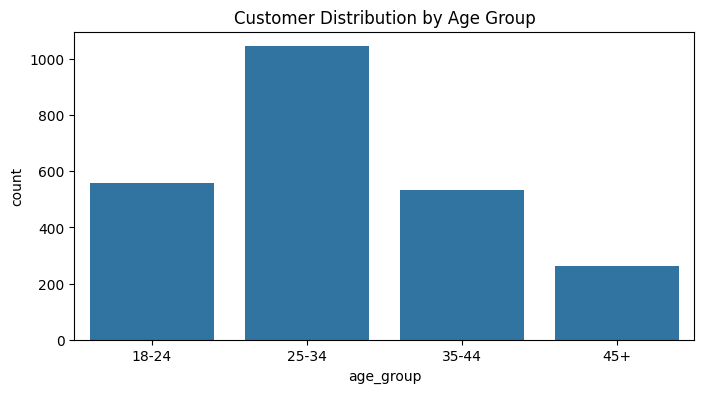

In [14]:
#Age group distributtion chart
plt.figure(figsize=(8,4))
sns.countplot(data=customers, x="age_group")
plt.title("Customer Distribution by Age Group")
plt.show()

Observation:
Most customers belong to the dominant age segments, indicating the brand's primary customer base.

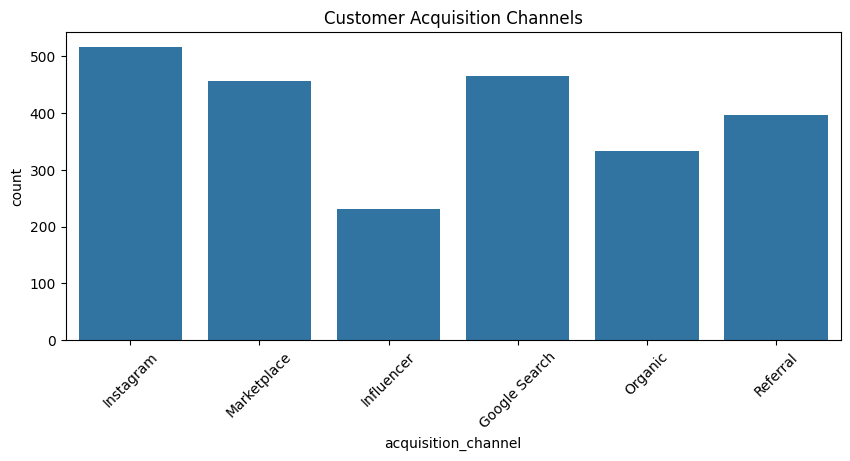

In [15]:
#Aquisition channel
plt.figure(figsize=(10,4))
sns.countplot(data=customers, x="acquisition_channel")
plt.xticks(rotation=45)
plt.title("Customer Acquisition Channels")
plt.show()

Observation:
Customer acquisition is concentrated in a few marketing channels.

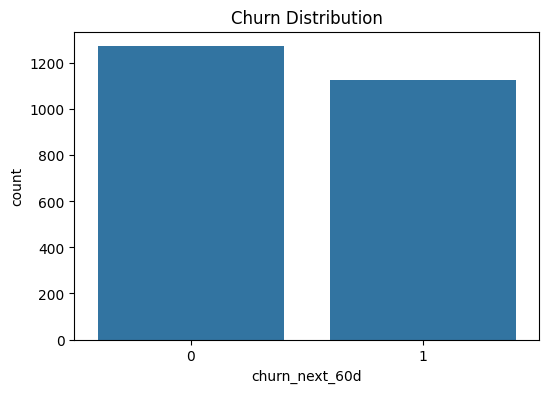

In [16]:
#churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=churn, x="churn_next_60d")
plt.title("Churn Distribution")
plt.show()

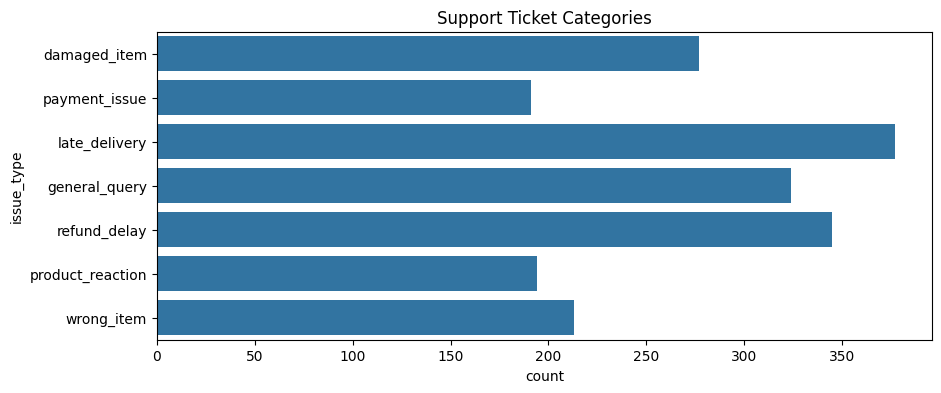

In [17]:
#Support ticket cateogaries
plt.figure(figsize=(10,4))
sns.countplot(data=tickets, y="issue_type")
plt.title("Support Ticket Categories")
plt.show()

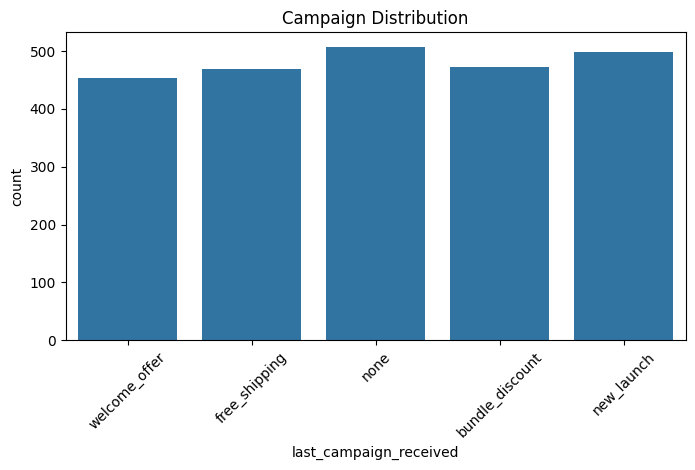

In [18]:
#Compaign Distribution
plt.figure(figsize=(8,4))
sns.countplot(data=interventions, x="last_campaign_received")
plt.xticks(rotation=45)
plt.title("Campaign Distribution")
plt.show()

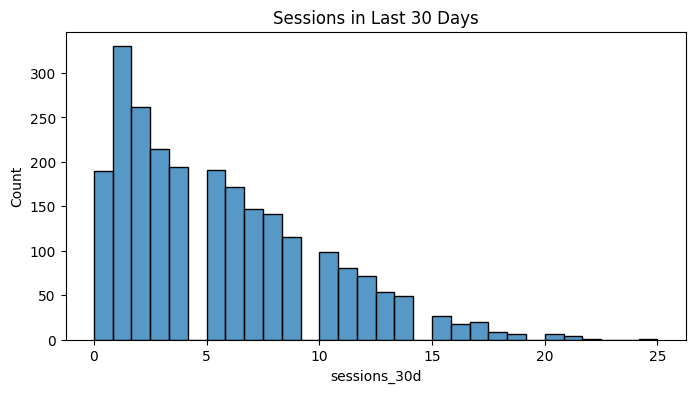

In [19]:
#Wev Sessions
plt.figure(figsize=(8,4))
sns.histplot(web["sessions_30d"], bins=30)
plt.title("Sessions in Last 30 Days")
plt.show()

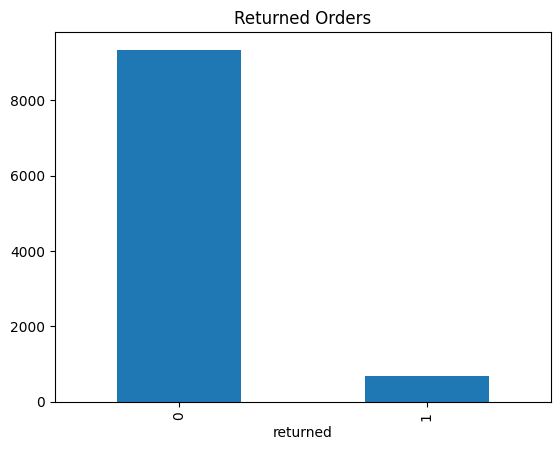

In [20]:
#Returned Orders
orders["returned"].value_counts().plot(kind="bar")
plt.title("Returned Orders")
plt.show()

# Churn Risk Hypotheses

## Hypothesis 1: Low Website Engagement Increases Churn Risk

Customers with fewer website sessions, product views, wishlist additions, and campaign interactions are more likely to churn because they demonstrate lower engagement with the brand. Reduced digital activity may indicate declining purchase intent and weaker customer loyalty.

**Supporting Evidence:**

* Web activity analysis shows varying levels of customer engagement.
* Customers with low sessions and product views represent a potentially disengaged segment.

---

## Hypothesis 2: Frequent Support Issues Increase Churn Risk

Customers who raise multiple support tickets may be more likely to churn, particularly when issues remain unresolved for longer periods or require reopening. Repeated service interactions often indicate dissatisfaction with the customer experience.

**Supporting Evidence:**

* Support ticket data shows substantial variation in issue frequency and resolution time.
* Common complaint categories may represent recurring customer pain points.

---

## Hypothesis 3: High Product Return Behaviour Correlates with Churn

Customers who frequently return products may be less satisfied with their purchases and therefore more likely to discontinue future purchases. Return behaviour can act as an early warning indicator of dissatisfaction.

**Supporting Evidence:**

* Return analysis shows a subset of customers returning products.
* High return rates may indicate product quality, expectation mismatch, or delivery-related concerns.

---

## Hypothesis 4: Low Purchase Frequency Indicates Higher Churn Risk

Customers with fewer historical purchases are likely to have weaker brand attachment and lower long-term commitment. Infrequent buyers may be more vulnerable to switching to competitors.

**Supporting Evidence:**

* Order behaviour analysis reveals significant variation in customer purchase frequency.
* Customers with minimal purchasing activity may require targeted engagement initiatives.

---

## Hypothesis 5: Campaign Non-Responsiveness Signals Potential Churn

Customers who receive marketing or retention campaigns but continue to show low engagement may be at elevated churn risk. Traditional promotional strategies may not be sufficient for these customers.

**Supporting Evidence:**

* Campaign history indicates different intervention types across customers.
* Continued inactivity after campaign exposure may suggest declining customer interest.

---

## Summary

The exploratory analysis suggests that customer engagement, support experience, return behaviour, purchase frequency, and campaign responsiveness are key factors that may influence churn. These hypotheses should be further validated through segmentation analysis and predictive modeling in subsequent stages of the project.


In [21]:
churn["churn_next_60d"].value_counts()

,count
churn_next_60d,
0,1273
1,1127


### Business Recommendations

1. Prioritize retention efforts for customers showing declining web engagement.

2. Investigate customers with repeated support complaints and long resolution times.

3. Review product categories associated with higher return behaviour.

4. Use customer activity signals to identify at-risk customers before churn occurs.

5. Evaluate campaign effectiveness and personalize interventions instead of applying blanket discounts.